# LiteX based Flexible Front-End (FFE) Evaluation/Demo

![Block diagram](ffe_spi.svg)

### Setup
* Install FFE components (interposer and at least one RX and one TX slice)
* Connect one TX chain output to one RX chain input __including at least 20dB of attenuation__
* Define `adc_channel` and `dac_channel` below according to which RX/TX slice/chain you're using

# Attenuator address mapping

| slice_id | atten_id | channel | attenuator  |
|----------|--------|---------|-------------|
| 0        | 0      | DAC0    |             |
| 0        | 1      | DAC1    |             |
| 1        | 0      | DAC2    |             |
| 1        | 1      | DAC3    |             |
| 2        | 0      | DAC4    |             |
| 2        | 1      | DAC5    |             |
| 3        | 0      | DAC6    | no SPI      |
| 3        | 1      | DAC7    | no SPI      |
| 4        | 0      | ADC0    | PRE_FILTER  |
| 4        | 1      | ADC0    | POST_FILTER |
| 4        | 2      | ADC1    | PRE_FILTER  |
| 4        | 3      | ADC1    | POST_FILTER |
| 5        | 0      | ADC2    | PRE_FILTER  |
| 5        | 1      | ADC2    | POST_FILTER |
| 5        | 2      | ADC3    | PRE_FILTER  |
| 5        | 3      | ADC3    | POST_FILTER |
| 6        | 0      | ADC4    | PRE_FILTER  |
| 6        | 1      | ADC4    | POST_FILTER |
| 6        | 2      | ADC5    | PRE_FILTER  |
| 6        | 3      | ADC5    | POST_FILTER |
| 7        | 0      | ADC6    | PRE_FILTER  |
| 7        | 1      | ADC6    | POST_FILTER |
| 7        | 2      | ADC7    | PRE_FILTER  |
| 7        | 3      | ADC7    | POST_FILTER |

In [ ]:
from mimo_mts.overlay import MimoMtsOverlay
import numpy as np
from mimo_mts.utils.plot import plot_complex_wfm_stack
import matplotlib.pyplot as plt
import math
import time

# Note! minimum_attenuation is only 5.0 dB because it is assumed there is an extra ~20dB 
# of external loop attenuation
minimum_attenuation = 5.0

# Ensure these agree with your hardware setup
adc_channel = 2
dac_channel = 0

atten_steps = (0, 1, 2, 3, 5, 10, 20, 31.5)


def set_attenuation_dac(ol, ndac: int, atten_db: float):
    """Set external attenuation (FFE) for DAC number 'ndac'
    The Tx slices contain 1 attenuator.
    params:
        int ndac: 0-7 for ZCU208, 0-15 (evens) for ZCU216
        float atten_db: attenuation in dB (0-31.5 inclusive)
    """
    ol.ffe.slices[ndac // 2].attenuators[ndac % 2].set_db(atten_db)

def set_attenuation_adc(ol, adc_channel, atten_db_pre=None, atten_db_post=None):
    """Set external attenuation (FFE) for ADC number 'nadc'
    The Rx slices contain 2 attenuators (pre-amplifier and post-amplifier), so there are two
    attenuation parameters.
    params:
        int nadc: 0-7 for ZCU208, 0-15 (evens) for ZCU216
        float atten_db_pre/post: attenuation in dB (0-31.5 inclusive)
                                 set to None to skip programming the associated attenuator (leave it alone)
    """
    # FIXME make offset depend on number of DAC channels
    slice_id = adc_channel // 2 + 4
    atten_id = (adc_channel % 2) * 2
    if atten_db_pre is not None:
        ol.ffe.slices[slice_id].attenuators[atten_id].set_db(atten_db_pre)
    if atten_db_post is not None:
        ol.ffe.slices[slice_id].attenuators[atten_id + 1].set_db(atten_db_post)

def get_dsp_waveform():
    """
    Get the DSP waveform from the ADC buffer.
    Average ADC data by 2 samples, as the same to the LLRF DSP,
    equivalent to a low pass filter to get base band signal.
    """
    darray_i, darray_q = ol.capture_adc_iq_buf()
    cdata = darray_i + 1j*darray_q
    return cdata.reshape(8, -1, 2).mean(axis=2)

def get_adc_rms():
    '''returns RMS power for all 8 ADC channels, averaged over 16k samples'''
    cdata_dsp = get_dsp_waveform()
    rms = np.sqrt(np.mean(np.abs(cdata_dsp)**2, axis=1))
    return rms

def test_ffe_linearity(atten_steps, rx_not_tx=True, pre_not_post=True, verbose=False):
    results = {}
    for atten in atten_steps:
        if verbose:
            print(f"Atten = {atten} dB")
        #ol.ffe.config_rx_slice(nslice=4, ch0_atten_db_pre=0, ch0_atten_db_post=atten)
        if rx_not_tx:
            if pre_not_post:
                set_attenuation_adc(ol, adc_channel, atten_db_pre=atten, atten_db_post=None)
            else:
                set_attenuation_adc(ol, adc_channel, atten_db_pre=None, atten_db_post=atten)
        else:
            set_attenuation_dac(ol, dac_channel, atten_db=atten)
        time.sleep(0.1)
        cdata_dsp = get_dsp_waveform()
        wfm = cdata_dsp[adc_channel, :1000]
        amp = np.abs(wfm)
        avg = np.average(amp)
        if verbose:
            print(f"avg = {avg}")
        results[atten] = avg
    return results

def plot_ffe_linearity(results, title=""):
    unit = 0
    # un-comment to plot attenuation = pout - pin
    # unit = 10*math.log10(results[0]**2)
    rdb = {key: 10*math.log10(val**2)-unit for key, val in results.items()}
    x = [key for key in rdb.keys()]
    y = [val for val in rdb.values()]
    plt.plot(x, y, marker='o')
    plt.title(title)
    plt.xlabel("Attenuation Setting (dB)")
    plt.ylabel("Received Power (log-scale)")
    plt.grid()
    plt.show()
    return

In [2]:
ol = MimoMtsOverlay(config='ALS_LLRF_LBL208')

fs = ol.adc_sampling_rate / 8  # decimation / interpolation

ol.rf_control.register_map.trig_sel=0
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.dac_enable.pulse_enable=0
ol.rf_control.register_map.amp_loop_setpoint = 32767 / (4*ol.rf_control.tx_gain)

Overlay(/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/overlays/als_llrf_mts.bit, None, download=True
Bitstream(/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/overlays/als_llrf_mts.bit, None)
self.dtbo = None
Powering up and initializing analog frontend ...
Set DAC mixer: freq=-3000 MHz, nyquist=2, phase=0 degrees
Set ADC mixer: freq=3000 MHz, nyquist=2, phase=0 degrees


## Check which slices are present

In [8]:
is_present = []
for slice_id, sl in enumerate(ol.ffe.slices):
    if sl is None:
        print(f'slice{slice_id} does not have a SPI bus')
        continue
    if sl.is_present():
        print(f'slice{slice_id} is present')
        is_present.append(slice_id)

slice3 does not have a SPI bus
slice4 is present
slice5 is present
slice6 is present
slice7 is present


## Sensor readback

In [12]:
for slice_id in is_present:
    sl = ol.ffe.slices[slice_id]
    for sensor_id, sensor in enumerate(sl.sensors):
        print(f'slice{slice_id}, INA239_{sensor_id}: {sensor.get_voltage():6.3f} V  {sensor.get_current() * 1000:6.1f} mA  {sensor.get_temperature():6.1f} degC')

slice4, INA239_0:  5.013 V   -92.7 mA    38.6 degC
slice4, INA239_1:  4.981 V   -84.7 mA    39.0 degC
slice4, INA239_2:  4.991 V    -2.7 mA    38.9 degC
slice5, INA239_0:  4.984 V   -84.8 mA    40.4 degC
slice5, INA239_1:  5.000 V   -85.1 mA    40.4 degC
slice5, INA239_2:  4.994 V    -2.7 mA    39.5 degC
slice6, INA239_0:  5.000 V   -85.3 mA    38.9 degC
slice6, INA239_1:  4.997 V   -84.1 mA    39.1 degC
slice6, INA239_2:  5.006 V    -2.5 mA    39.6 degC
slice7, INA239_0:  5.016 V   -86.0 mA    38.0 degC
slice7, INA239_1:  4.994 V   -86.0 mA    38.0 degC
slice7, INA239_2:  5.013 V    -2.7 mA    37.9 degC


## Which ADC channels see power?
There is a single loopback cable installed. 1 Channel should see significantly more power than the other ones.

In [17]:
# Disable all attenuators
for slice_id in is_present:
    sl = ol.ffe.slices[slice_id]
    for hmc in sl.attenuators:
        hmc.set_db(0)

In [18]:
get_adc_rms()

array([7.15327918e+00, 7.46376337e+00, 5.68306215e+00, 6.27114709e+00,
       1.13306818e+04, 6.78049616e+00, 7.41813331e+00, 6.52965880e+00])

# RX Pre-Attenuation Linearity Test

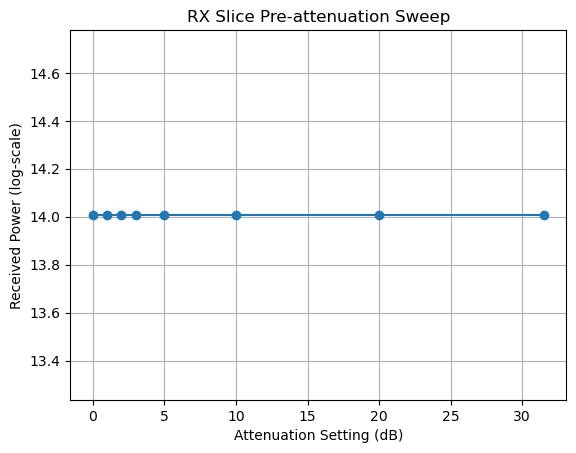

In [21]:
# Set TX attenuation
set_attenuation_dac(ol, dac_channel, minimum_attenuation)
# Set fixed RX post attenuation
set_attenuation_adc(ol, adc_channel, atten_db_pre=None, atten_db_post=0)
results = test_ffe_linearity(atten_steps, rx_not_tx=True, pre_not_post=True, verbose=False)
plot_ffe_linearity(results, title="RX Slice Pre-attenuation Sweep")

# RX Post-Attenuation Linearity Test

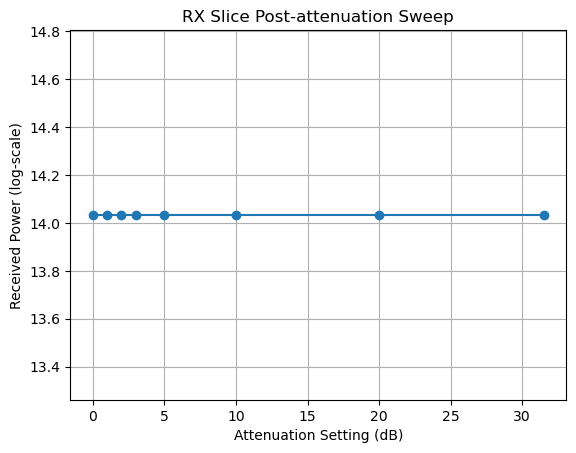

In [22]:
# Set TX attenuation
set_attenuation_dac(ol, dac_channel, minimum_attenuation)
# Set fixed RX pre attenuation
set_attenuation_adc(ol, adc_channel, atten_db_pre=0, atten_db_post=None)
results = test_ffe_linearity(atten_steps, rx_not_tx=True, pre_not_post=False, verbose=False)
plot_ffe_linearity(results, title="RX Slice Post-attenuation Sweep")

# TX Attenuation Linearity Test

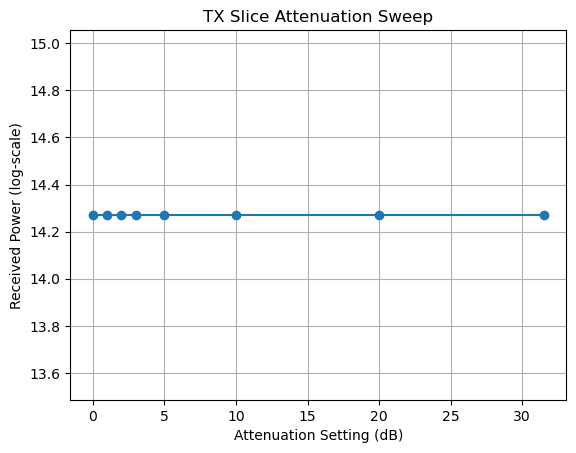

In [23]:
# Set fixed RX pre and post attenuation
set_attenuation_adc(ol, adc_channel, atten_db_pre=minimum_attenuation, atten_db_post=0.0)
results = test_ffe_linearity(atten_steps, rx_not_tx=False, verbose=False)
plot_ffe_linearity(results, title="TX Slice Attenuation Sweep")

# Disable all slices (set to maximum attenuation) for safety

In [24]:
# Set all attenuators to the max.
for slice_id in is_present:
    sl = ol.ffe.slices[slice_id]
    for hmc in sl.attenuators:
        hmc.set_db(31.5)